In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.figure(figsize=(10,6))
sns.set(style="whitegrid")

<Figure size 1000x600 with 0 Axes>

In [3]:
df = pd.read_csv("demand_forecasting.csv")

In [4]:
df.head(1000)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2022-01-10,S005,P0016,Toys,North,518,86,0,31.25,10,Cloudy,0,35.52,Winter,0,92
996,2022-01-10,S005,P0017,Toys,North,155,118,165,42.06,10,Cloudy,1,36.76,Winter,0,149
997,2022-01-10,S005,P0018,Clothing,North,116,116,161,22.21,10,Cloudy,1,26.36,Winter,0,135
998,2022-01-10,S005,P0019,Furniture,North,97,97,213,141.81,10,Cloudy,0,139.44,Winter,0,95


In [5]:
df["Epidemic"].value_counts()

Epidemic
0    60800
1    15200
Name: count, dtype: int64

In [6]:
df.dtypes

Date                      str
Store ID                  str
Product ID                str
Category                  str
Region                    str
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition         str
Promotion               int64
Competitor Pricing    float64
Seasonality               str
Epidemic                int64
Demand                  int64
dtype: object

In [7]:
df["Date"] = pd.to_datetime(df["Date"])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[us]
 1   Store ID            76000 non-null  str           
 2   Product ID          76000 non-null  str           
 3   Category            76000 non-null  str           
 4   Region              76000 non-null  str           
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  str           
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null  str           
 14  E

In [9]:
#checking for missing values
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [10]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

In [11]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,76000,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
Inventory Level,76000.0,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
Units Sold,76000.0,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
Units Ordered,76000.0,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
Price,76000.0,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
Discount,76000.0,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
Promotion,76000.0,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
Competitor Pricing,76000.0,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
Epidemic,76000.0,0.2,0.0,0.0,0.0,0.0,1.0,0.400003
Demand,76000.0,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801


In [12]:
# Summary statistics for categorical columns
df.describe(include="object").T

C:\Users\monda\AppData\Local\Temp\ipykernel_16184\3118575569.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
Store ID,76000,5,S001,15200
Product ID,76000,20,P0001,3800
Category,76000,5,Groceries,30400
Region,76000,4,North,30400
Weather Condition,76000,4,Cloudy,24360
Seasonality,76000,4,Winter,21000


In [13]:
df.head(2)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229


In [14]:
#seperating the date column into day, month and year
df["day"] = df["Date"].dt.day
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["Weekday"] = df["Date"].dt.day_name()

In [15]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand', 'day', 'month', 'year', 'Weekday'],
      dtype='str')

In [16]:
df["Discounted Price"] = df["Price"] - (df["Price"] * df["Discount"]/100)

In [17]:
df["Sell Through Rate"] = df["Units Sold"] / df["Inventory Level"]

In [18]:
df.head(5)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,day,month,year,Weekday,Discounted Price,Sell Through Rate
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,1,1,2022,Saturday,69.084,0.523077
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,1,1,2022,Saturday,68.136,1.000000
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,1,1,2022,Saturday,56.646,0.461538
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,1,1,2022,Saturday,78.867,0.323741
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,1,1,2022,Saturday,54.410,0.427632


In [19]:
df["Sell Through Rate"].describe()

count    75594.000000
mean         0.437580
std          0.298007
min          0.003150
25%          0.190807
50%          0.350475
75%          0.642276
max          1.000000
Name: Sell Through Rate, dtype: float64

In [20]:
df.groupby("Category")["Demand"].agg(["mean", "sum", "std"]).sort_values(by="sum", ascending=False).reset_index()

,Category,mean,sum,std
0,Groceries,120.976447,3677684,48.362730
1,Clothing,112.619737,1369456,41.022968
2,Furniture,73.581140,1006590,32.336141
3,Toys,92.606955,985338,46.170390
4,Electronics,97.482018,889036,40.557859


The demand for groceries is maximum w.r.t. all other catagories

In [21]:
df.groupby(["Region", "Seasonality"])["Demand"].mean()

Region  Seasonality
East    Autumn         106.353297
        Spring         100.168478
        Summer         115.388315
        Winter         104.273571
North   Autumn         103.065797
        Spring          97.399457
        Summer         112.843750
        Winter         102.017738
South   Autumn         104.464560
        Spring         100.328804
        Summer         115.089946
        Winter         107.733095
West    Autumn         100.165385
        Spring          93.219293
        Summer         108.111141
        Winter         100.988810
Name: Demand, dtype: float64

In every region and seasonality, we can see the average demand. This can help us understand which regions and seasons have higher demand for our products. For example in every region summer has higher demand than winter. 

In [22]:
df.groupby("Promotion")["Demand"].mean()

Promotion
0     95.026843
1    123.269400
Name: Demand, dtype: float64

Discount effecting demend clearly 

In [23]:
#monthly demand trend of different categories
pd.pivot_table(df, values = "Demand", index = "month", columns = "Category", aggfunc = "mean")

Category,Clothing,Electronics,Furniture,Groceries,Toys
month,,,,,
1,126.997962,99.519022,75.690821,117.399457,94.242236
2,128.966518,84.184524,61.625992,103.522768,68.885204
3,105.835685,108.120968,84.015233,126.561694,128.273041
4,106.972917,85.916667,63.005556,105.111250,85.753571
5,108.650202,79.577957,56.036738,98.637903,71.756912
6,105.670833,106.922222,79.908333,147.772500,100.825000
7,107.838710,87.418011,66.156810,128.744355,74.366359
8,107.871976,109.733871,83.524194,149.875403,102.794931
9,105.118750,105.015278,81.854630,122.239167,102.722619


<Axes: xlabel='month'>

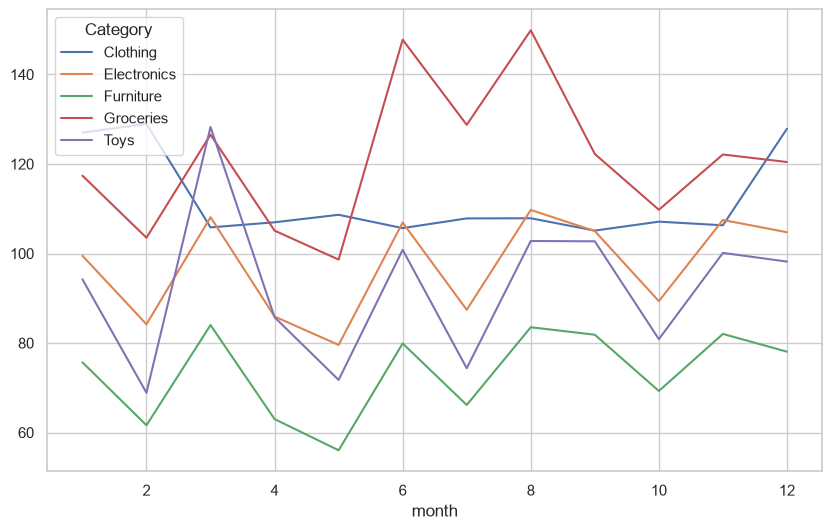

In [24]:
#plot of #monthly demand trend of different categories
pd.pivot_table(df, values = "Demand", index = "month", columns = "Category", aggfunc = np.mean).plot(figsize=(10,6))

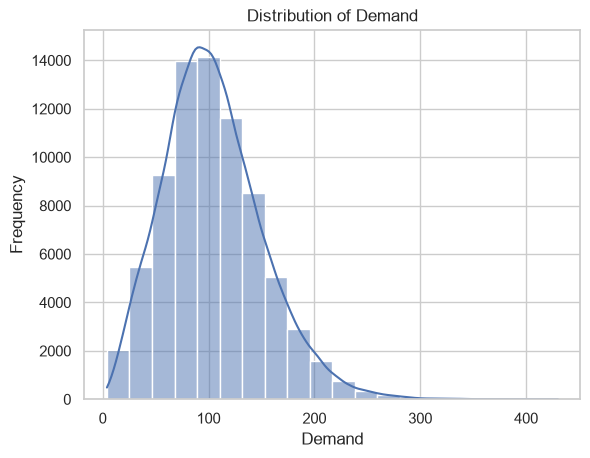

In [25]:
sns.histplot(df["Demand"], bins = 20, kde = True)
plt.title("Distribution of Demand")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.show()

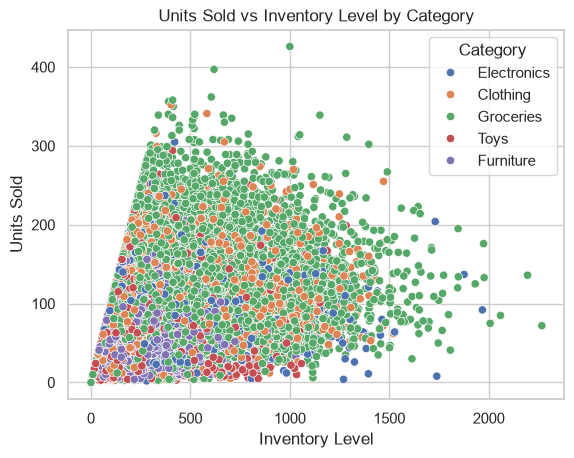

In [26]:
#scatter plot of Unit Sold vs Inventory Level
sns.scatterplot(data=df, x="Inventory Level", y="Units Sold", hue="Category")
plt.title("Units Sold vs Inventory Level by Category")
plt.xlabel("Inventory Level")
plt.ylabel("Units Sold")
plt.show()

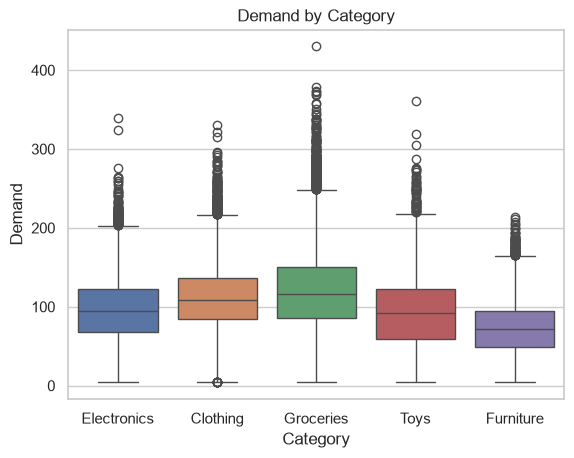

In [27]:
#boxplot of Demand by Category
sns.boxplot(data=df, x="Category", y="Demand", hue="Category")
plt.title("Demand by Category")
plt.xlabel("Category")
plt.ylabel("Demand")
plt.show()

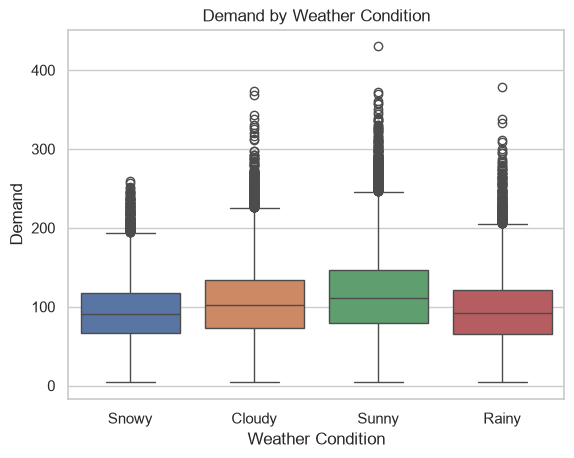

In [28]:
#boxplot of demand by weather condition
sns.boxplot(data=df, x="Weather Condition", y="Demand", hue="Weather Condition")
plt.title("Demand by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Demand")
plt.show()        

Time Series Analysis

In [29]:
monthly_demand = df.groupby("month")["Demand"].mean()

In [30]:
monthly_demand

month
1     106.040000
2      92.882500
3     113.613871
4      92.816667
5      86.521129
6     117.346000
7     101.561613
8     119.803387
9     107.431500
10     95.557258
11    107.542333
12    109.003226
Name: Demand, dtype: float64

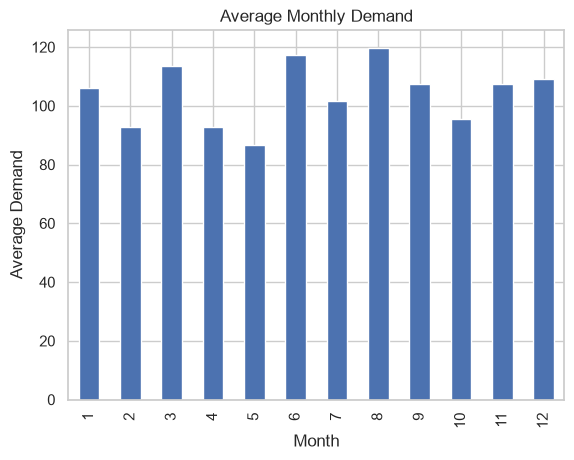

In [31]:
monthly_demand.plot(kind="bar")
plt.title("Average Monthly Demand")
plt.xlabel("Month")
plt.ylabel("Average Demand")
plt.show()  

In [32]:
daily_demand = df.groupby("Date")["Demand"].sum()

In [33]:
daily_demand

Date
2022-01-01    10060
2022-01-02    10814
2022-01-03    11317
2022-01-04    11469
2022-01-05    11724
              ...  
2024-01-26    11182
2024-01-27    11540
2024-01-28    11440
2024-01-29    10268
2024-01-30     9657
Name: Demand, Length: 760, dtype: int64

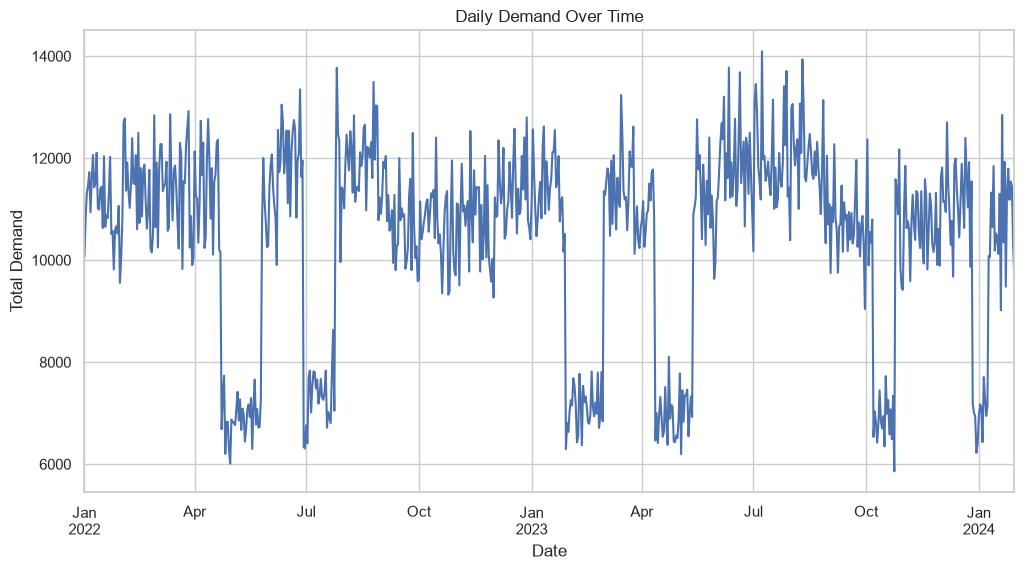

In [34]:
daily_demand.plot(kind="line", figsize=(12,6))
plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Demand")
plt.show()  

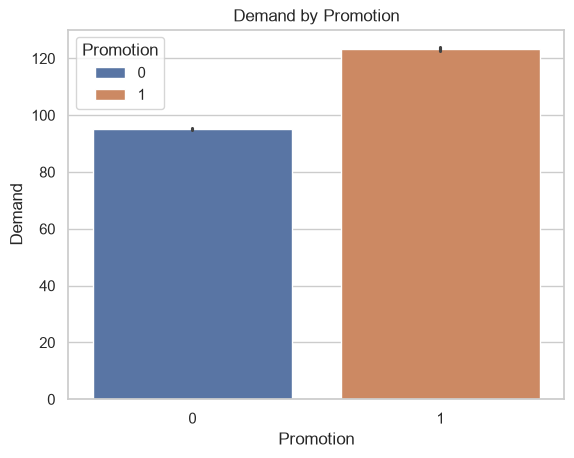

In [35]:
sns.barplot(data = df, x = "Promotion", y = "Demand", hue = "Promotion")
plt.title("Demand by Promotion")
plt.xlabel("Promotion")
plt.ylabel("Demand")
plt.show()

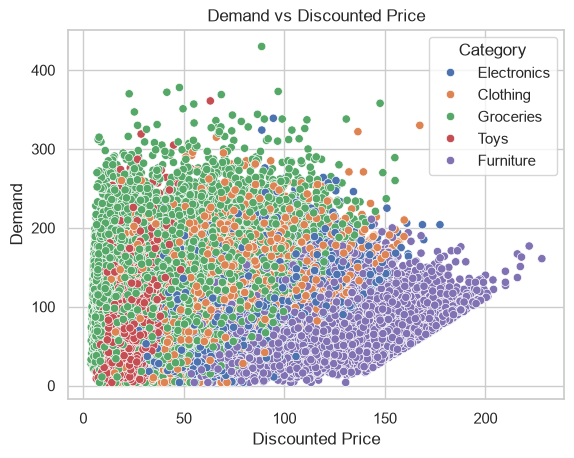

In [36]:
sns.scatterplot(data=df, x="Discounted Price", y="Demand", hue="Category")
plt.title("Demand vs Discounted Price")
plt.xlabel("Discounted Price")
plt.ylabel("Demand")
plt.show()

<Axes: title={'center': 'Average Demand by Seasonality'}, xlabel='Seasonality'>

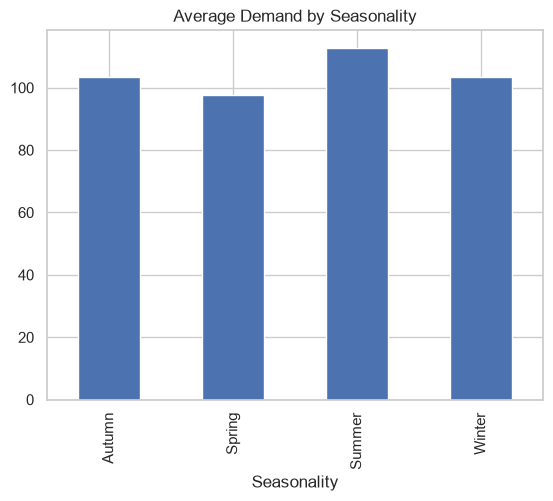

In [37]:
df.groupby("Seasonality")["Demand"].mean().plot(kind="bar", title="Average Demand by Seasonality")

<Axes: title={'center': 'Average Demand by Epidemic'}, xlabel='Epidemic'>

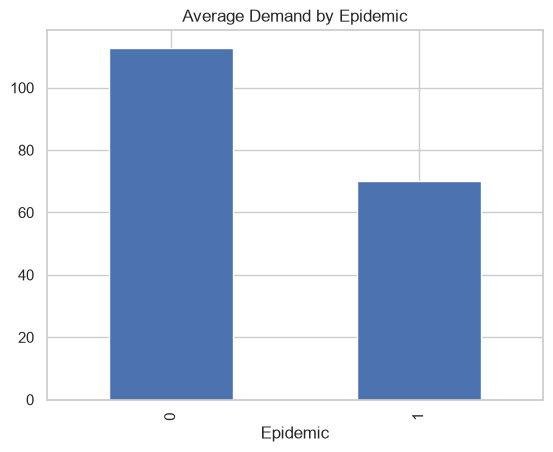

In [38]:
df.groupby("Epidemic")["Demand"].mean().plot(kind="bar", title="Average Demand by Epidemic")

In [39]:
from pathlib import Path

project_folder = Path(
    r"C:\Users\monda\OneDrive - Indian Institute of Science\PythonForML\Demand Forecasting"
)

project_folder.mkdir(parents=True, exist_ok=True)

print("Folder exists:", project_folder.exists())

Folder exists: True


In [40]:
df.to_csv(
    project_folder / "preprocessed_data.csv",
    index=False
)

print("Preprocessed data saved successfully!")

Preprocessed data saved successfully!
